In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import * # noqa

In [239]:
import pyagrum as gum
import numpy as np

def resample_bn_params(bn: gum.BayesNet, alpha: float = 1.0, prob: float = 1.0) -> gum.BayesNet:
    """
    Copy the `bn` structure and resample its parameters from a Dirichlet distribution.
    Here, `prob` is the probability that a conditional X|\pi_X is resampled.
    The output is the resampled BN (`bn_new`) and a mask BN (`bn_mask`).
    The latter indicates the differences between `bn` and `bn_new` (1 = equal, 0 = different).
    """
    bn_new = gum.BayesNet(bn)
    bn_mask = gum.BayesNet(bn)

    for node_id in bn_new.nodes():
        cpt = bn_new.cpt(node_id)
        var_size = bn_new.variable(node_id).domainSize()
        n_rows = cpt.domainSize() // var_size

        samples = np.random.dirichlet(
            alpha=[alpha] * var_size,
            size=n_rows
        )

        mask = np.ones(samples.shape)

        for row in range(n_rows):
            if np.random.choice([True, False], p=[prob, 1.0 - prob]):
                mask[row, :] = 0

        cpt_resh = cpt[:].reshape(n_rows, var_size)

        cpt_new = mask*cpt_resh[:] + (1-mask) * samples

        cpt.fillWith(cpt_new.flatten().tolist())
        bn_mask.cpt(node_id).fillWith(mask.flatten().tolist())

        # Debug
        safe_assert(np.allclose(np.sum(cpt_resh, axis=1), 1))

    return bn_new, bn_mask

In [240]:
# Test
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")
for prob in [0.0, 0.5, 1.0]:

    for _ in range(5):
        
        bn_new, bn_mask = resample_bn_params(bn_base, prob=prob)

        for node_id in bn_base.nodes():
            cpt = bn_base.cpt(node_id)[:]
            cpt_new = bn_new.cpt(node_id)[:]
            cpt_and = np.array(cpt == cpt_new, dtype=int)

            assert(np.allclose(cpt_and - bn_mask.cpt(node_id)[:], 0))

In [241]:
class Client:
    n_clients = 0

    def __init__(self, gt: gum.BayesNet):
        self.label = Client.n_clients
        Client.n_clients += 1     

        # Set the client's ground-truth BN
        self.gt= gt

        # Set other args to None
        self.data = None
        self.bn = None
        self.bn_counts = None
        self.cn = None
        self.ess = None


    def check(self, attributes: list):
        for a in attributes:
            if getattr(self, a) is None:
                raise RuntimeError(f"Attribute '{a}' is missing.")
        

    def generate_data(self, size: int) -> None:
        '''
        Generate client's data based on self.gt.
        '''
    
        gen = gum.BNDatabaseGenerator(self.gt)
        gen.drawSamples(size)
        self.data = gen.to_pandas()
    
    def learn_bn(self) -> None:
        '''
        Learn the BN parameters by MLE, provided the DAG structure.
        '''
        self.check(["data"])
        self.bn = learn_bn_params(self.gt, self.data)
        

    def learn_cn(self, ess: int) -> None:
        '''
        Learn the CN by local IDM, provided the DAG structure.
        '''
        self.check(["data", "bn"])
        self.bn_counts = get_bn_counts(self.bn, self.data)
        cn = gum.CredalNet(self.bn_counts)
        cn.idmLearning(ess)

        self.ess = ess
        self.cn = cn
        
    def get_cset(self, var:str, parents:dict = None) -> np.array:
        ''' 
        Get the credal set `var`|`parents`, .
        If `parents` is None, return all csets.
        '''

        self.check(["cn"])
        
        bn_min, bn_max = get_min_max_bns(self.cn)
        cpt_min, cpt_max = bn_min.cpt(var)[:], bn_max.cpt(var)[:]
        cpt_min, cpt_max = get_tabular_cpt(cpt_min), get_tabular_cpt(cpt_max)

        if parents is None: return cpt_min, cpt_max
        
        parents_idx = find_cpt_index(self.gt, var, parents)
        row_min = np.atleast_2d(cpt_min[parents_idx,:])
        row_max = np.atleast_2d(cpt_max[parents_idx,:])
        return row_min, row_max


    def update_cset(self, var:str, prior: tuple = None, parents:dict = None) -> tuple:

        ''' 
        Update the credal set `var`|`parents`, given a `prior`.
        If `parents` is None, update all csets.
        `prior` is a pair of (prior_min, prior_max).
        '''

        self.check(["cn", "bn", "bn_counts"])

        # No prior means no update
        if prior is None: return self.get_cset(var)
        
        prior_min = get_tabular_cpt(prior[0])
        prior_max = get_tabular_cpt(prior[1])
        
        cpt_mle = get_tabular_cpt(self.bn.cpt(var))
        cpt_counts = get_tabular_cpt(self.bn_counts.cpt(var))
        ess = self.ess

        if parents and (prior_min.shape[0] != 1 or prior_max.shape[0] != 1): 
            raise RuntimeError(f"Please provide a prior of right shape. Actual shape: {prior_min.shape}")
        
        if parents or len(self.gt.parents(var)) == 0: 
            parents_idx = find_cpt_index(self.gt, var, parents)
            row_mle = cpt_mle[parents_idx, :]
            row_counts = cpt_counts[parents_idx, :]

            n_pi = np.sum(row_counts)

            new_row_min = n_pi/(n_pi + ess)*row_mle + ess/(n_pi + ess)*prior_min
            new_row_max = n_pi/(n_pi + ess)*row_mle + ess/(n_pi + ess)*prior_max

            # Debug
            row_min, row_max = self.get_cset(var, parents)
            safe_assert(np.all(new_row_min >= row_min))
            safe_assert(np.all(new_row_max <= row_max))
            safe_assert(np.all(prior_min <= prior_max))
            safe_assert(prior_min.shape == prior_max.shape)

            return new_row_min, new_row_max

        else:
            new_cpt = np.zeros((2,*cpt_mle.shape))

            index = self.bn.cpt(var).topandas().index
            index_df = index.to_frame(index=False)

            for i in range(len(index_df)):

                parents = dict(index_df.iloc[i])
                parents_idx = find_cpt_index(self.gt, var, parents)
                new_row_min, new_row_max = self.update_cset(var, (prior_min[parents_idx,:], prior_max[parents_idx,:]), parents)
                new_cpt[0, i, :] = new_row_min
                new_cpt[1, i, :] = new_row_max

            new_cpt_min = np.squeeze(new_cpt[0, ...])
            new_cpt_max = np.squeeze(new_cpt[1, ...])

            return new_cpt_min, new_cpt_max

In [242]:
class CsetFusion():

    def __init__(self, var:str, method: str, weighting: str = None):
        self.var = var
        self.method = method
        self.weighting = weighting

    def __call__(self, clients: list, parents:dict = None):

        if len(clients) == 1: return clients[0].get_cset(self.var)
        
        # Get the CPTs
        shape = clients[0].get_cset(self.var)[0].shape
        cpts = np.zeros((2, *shape, len(clients)))  #!
        for i in range(len(clients)):
            client =clients[i]
            cpt_min, cpt_max = client.get_cset(self.var)
            cpts[0, :, i] = cpt_min
            cpts[1, :, i] = cpt_max

        if self.method == "ConvComb":

            if self.weighting == "unif":
                w = 1/len(clients)
                cpts_sum = np.sum(cpts, axis=2) * w
                new_cpt_min, new_cpt_max = cpts_sum[0, ...], cpts_sum[1, ...]

                if parents is None:
                    return new_cpt_min, new_cpt_max
                else:
                    parents_idx = find_cpt_index(self.gt, self.var, parents)
                    return new_cpt_min[parents_idx,:], new_cpt_max[parents_idx,:]


            elif self.weighting is None:
                RuntimeError(f"Attribute 'weighting' is missing.")

            else:
                raise NotImplementedError(f"No '{self.weighting}' weighting implemented.")
            
        else:
            raise NotImplementedError(f"No '{self.method}' method implemented.")

### Example with 2 context nodes

In [243]:
# Create a baseline model
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")

# Generate clients
clients = {}
E, N = 2, 1000
for e in range(E):

    # Init the client
    p = 0 if e == 0 else .2
    gt, _ = resample_bn_params(bn_base, prob=p)
    client = Client(gt)

    # Generate data
    client.generate_data(size=N)

    # Learn the BN
    client.learn_bn()

    # Learn CNs
    client.learn_cn(ess=1)

    # Collect
    clients[e] = client

In [244]:
# Check the correctness of `update_cset` function
for e in range(len(clients)):
    assert(np.allclose(clients[e].get_cset("Y")[0], clients[e].update_cset("Y", [np.array([0., 0.]), np.array([1.,1.])])[0]))
    assert(np.allclose(clients[e].get_cset("X")[0], clients[e].update_cset("X", [np.array([[0., 0.],[0., 0.]]), np.array([[1.,1.],[1.,1.]])])[0]))

## Examples

In [245]:
def plot_update(client_num:int, var: str, parents: dict = None, prior: tuple = None):

    client = clients[client_num]
    parents_idx = find_cpt_index(client.bn, var, parents)
    prior_min, prior_max = np.atleast_2d(prior[0]), np.atleast_2d(prior[1])

    cset = client.get_cset(var, parents)
    plt.plot([cset[0][0,0], cset[1][0,0]], [cset[1][0,1], cset[0][0,1]], "-", 
             color="#2f82ff", linewidth=2, label="Local IDM")

    mle = get_tabular_cpt(client.bn.cpt(var))
    mle = mle[parents_idx,:]
    plt.scatter(mle[0], mle[1], marker="o", s=120, 
                color="#ffff00", edgecolors="black", label="MLE")

    prior = [prior_min[parents_idx, :], prior_max[parents_idx, :]]
    plt.plot([prior[0][0], prior[1][0]], [prior[1][1], prior[0][1]], "-", 
             color="#19A519", linewidth=5, label="Prior")

    cset_update = client.update_cset(var, prior, parents)
    plt.plot([cset_update[0][0,0], cset_update[1][0,0]], [cset_update[1][0,1], cset_update[0][0,1]], "-", 
             color="#e92828", linewidth=5, label="Updated Cset")
    
    print("Cset (IDM):\n", cset)
    print("\nMLE:\n", mle)
    print("\nUpdated cset:\n", cset_update)

    plt.legend(loc="best")
    plt.show()

In [246]:
for e in range(E):
    print(f"Client {e}:\n")
    gnb.showCPTs(clients[e].gt)

Client 0:



Client 1:



Cset (IDM):
 (array([[0.028971  , 0.97003001]]), array([[0.02997   , 0.97102898]]))

MLE:
 [0.029 0.971]

Updated cset:
 (array([[0.02900396, 0.97099504]]), array([[0.02900496, 0.97099604]]))


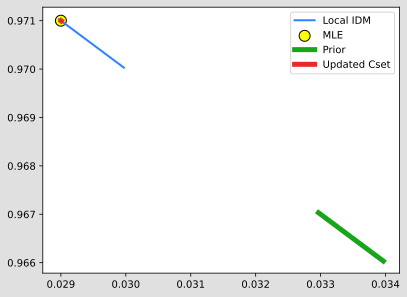

In [247]:
## Example 1: IID
# Set client, variable and parents
client_num = 0
var = "Y"
parents = None

# Set prior
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())
prior = CsetFusion(var, "ConvComb", "unif")(prior_clients)

# Plot
plot_update(client_num, var, parents, prior)

Cset (IDM):
 (array([[0.48559701, 0.51337397]]), array([[0.486626  , 0.51440299]]))

MLE:
 [0.48609681 0.51390319]

Updated cset:
 (array([[0.48563709, 0.51436184]]), array([[0.48563816, 0.51436291]]))


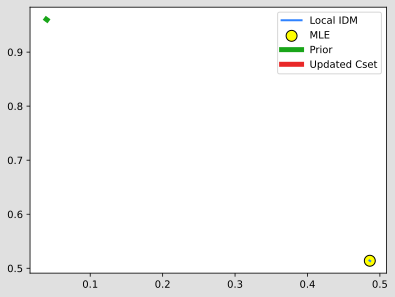

In [248]:
## Example 2: non-IID
# Set client, variable and parents
client_num = 0
var = "X"
parents = {"Y":"1"}

# Set prior
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())
prior = CsetFusion(var, "ConvComb", "unif")(prior_clients)

# Plot
plot_update(client_num, var, parents, prior)

Cset (IDM):
 (array([[0.22413801, 0.767241  ]]), array([[0.232759  , 0.77586198]]))

MLE:
 [0.22608696 0.77391304]

Updated cset:
 (array([[0.22585349, 0.77410362]]), array([[0.22589638, 0.77414651]]))


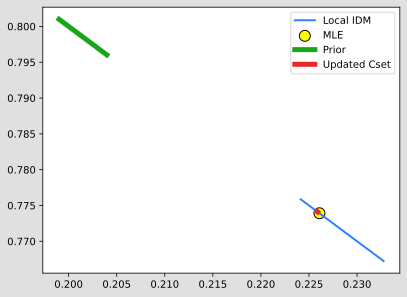

In [249]:
## Example 3
# Set client, variable and parents
client_num = 0
var = "Z"
parents = {"X":"1", "W": "0"}

# Set prior
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())
prior = CsetFusion(var, "ConvComb", "unif")(prior_clients)

# Plot
plot_update(client_num, var, parents, prior)